In [ ]:
import librosa
import soundfile as sf
import time
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
INPUT = 'p0002-7.mp3'
OUTPUT = 'output.wav'
audio, sr = librosa.load(INPUT, sr=None, mono=True)

### chunk

In [10]:
print("Sample rate:", sr)
print("Samples:", len(audio))
print("Duration:", len(audio) / sr, "seconds")

chunk_ms = 100
chunk_size = int(sr * chunk_ms / 1000)

output_chunks = []

for start in range(0, len(audio), chunk_size):
    chunk = audio[start: start + chunk_size]
    
    t0 = time.perf_counter()

    processed = chunk * 2

    elapsed_ms = (time.perf_counter() - t0) * 1000

    print(f"chunk inference: {elapsed_ms:.3f} ms")

    output_chunks.append(processed)

output_audio = np.concatenate(output_chunks)

sf.write(OUTPUT, output_audio, sr)

Sample rate: 48000
Samples: 3384939
Duration: 70.5195625 seconds
chunk inference: 0.235 ms
chunk inference: 0.018 ms
chunk inference: 0.012 ms
chunk inference: 0.011 ms
chunk inference: 0.012 ms
chunk inference: 0.012 ms
chunk inference: 0.010 ms
chunk inference: 0.012 ms
chunk inference: 0.012 ms
chunk inference: 0.013 ms
chunk inference: 0.012 ms
chunk inference: 0.014 ms
chunk inference: 0.012 ms
chunk inference: 0.012 ms
chunk inference: 0.011 ms
chunk inference: 0.010 ms
chunk inference: 0.012 ms
chunk inference: 0.011 ms
chunk inference: 0.011 ms
chunk inference: 0.011 ms
chunk inference: 0.012 ms
chunk inference: 0.011 ms
chunk inference: 0.012 ms
chunk inference: 0.012 ms
chunk inference: 0.012 ms
chunk inference: 0.010 ms
chunk inference: 0.012 ms
chunk inference: 0.012 ms
chunk inference: 0.011 ms
chunk inference: 0.012 ms
chunk inference: 0.012 ms
chunk inference: 0.011 ms
chunk inference: 0.012 ms
chunk inference: 0.012 ms
chunk inference: 0.011 ms
chunk inference: 0.012 ms

### waveform, spectrogram

sample rate: 48000
duration: 70.5195625


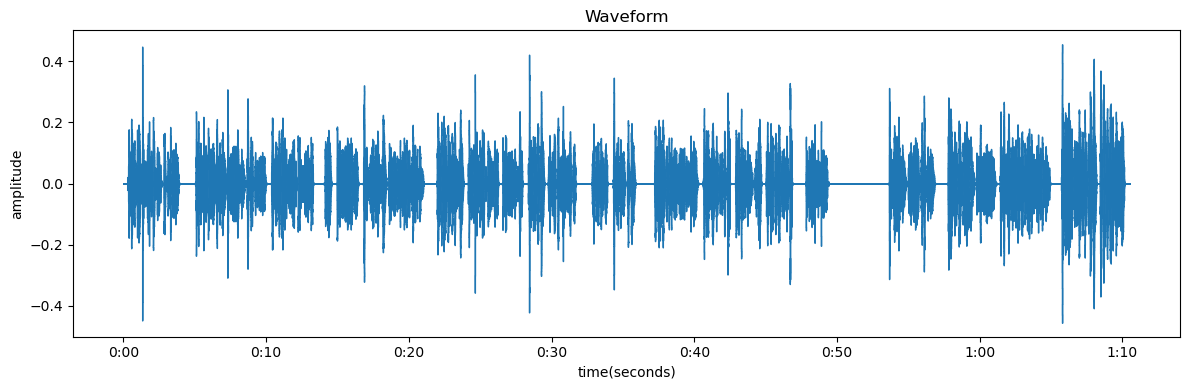

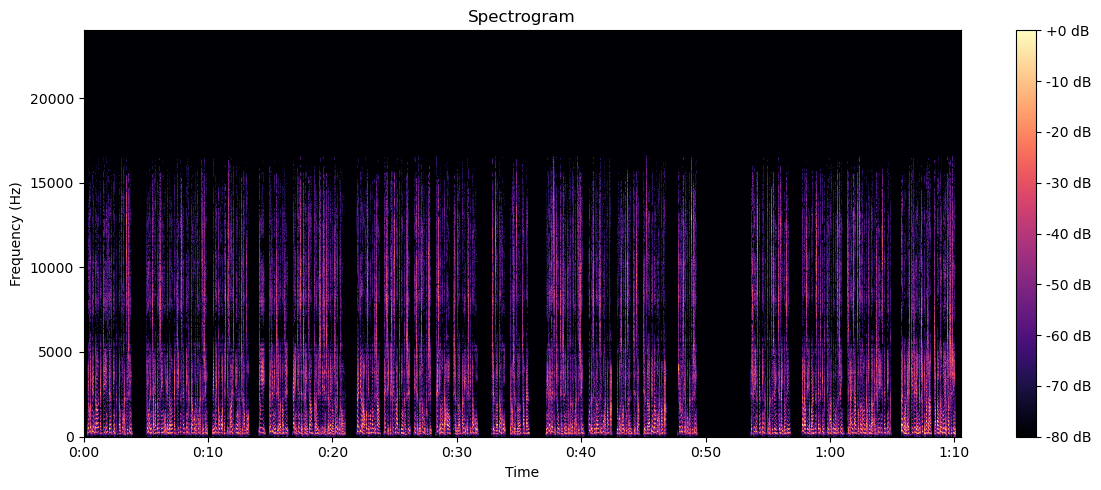

In [15]:
print("sample rate:", sr)
print("duration:", len(audio) / sr)

# ============================
# Waveform
# ============================

plt.figure(figsize=(12, 4))
librosa.display.waveshow(audio, sr=sr)

plt.title("Waveform")
plt.xlabel("time(seconds)")
plt.ylabel("amplitude")
plt.tight_layout()
plt.show()

# ============================
# Spectrogram
# ============================

stft = librosa.stft(audio)

magnitude = np.abs(stft)

db = librosa.amplitude_to_db(magnitude, ref=np.max)

plt.figure(figsize=(12, 5))

librosa.display.specshow(
    db,
    sr=sr,
    x_axis="time",
    y_axis="hz"
)

plt.colorbar(format="%+2.0f dB")

plt.title("Spectrogram")
plt.xlabel("Time")
plt.ylabel("Frequency (Hz)")

plt.tight_layout()
plt.show()

### f0

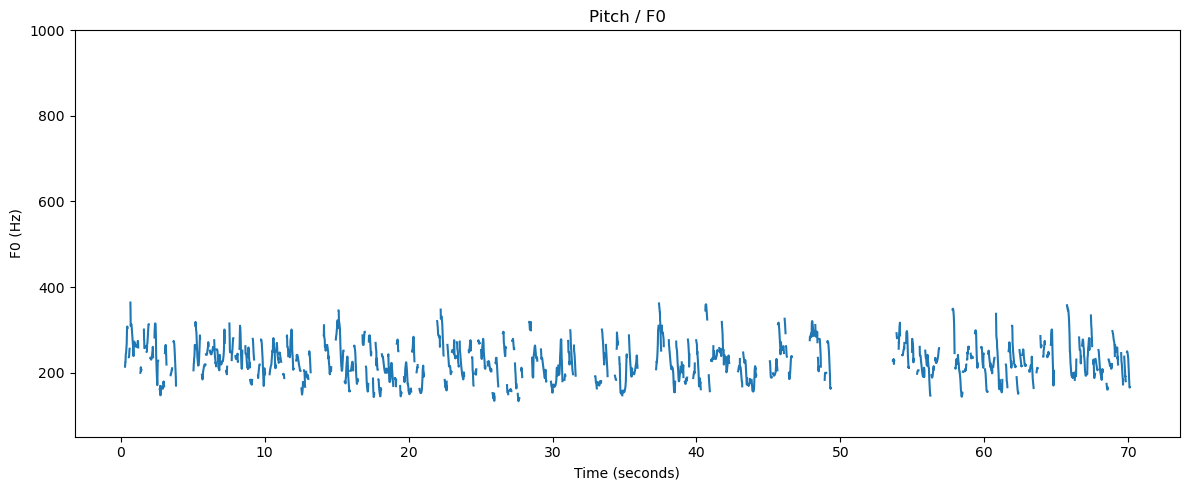

In [24]:
hop_length = 512

f0, voiced_flag, voiced_prob = librosa.pyin(
    audio,
    fmin=librosa.note_to_hz('C2'),
    fmax=librosa.note_to_hz('C6'),
    sr=sr,
    hop_length=hop_length
)
f0_times = librosa.times_like(f0, sr=sr, hop_length=hop_length)

plt.figure(figsize=(12, 5))
plt.plot(times, f0)
plt.xlabel("Time (seconds)")
plt.ylabel("F0 (Hz)")
plt.title("Pitch / F0")
plt.ylim(50, 1000)
plt.tight_layout()
plt.show()

In [29]:
sample_times = np.arange(len(audio)) / sr

valid = ~np.isnan(f0)

f0_interp = np.interp(
    sample_times,
    f0_times[valid],
    f0[valid]
)

phase_increment = 2 * np.pi * f0_interp / sr

phase = np.cumsum(phase_increment)

output = 10 * np.sin(phase)
sf.write(OUTPUT, output, sr)

### rvc